In [1]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))

ERROR: Error in library(ArchR): there is no package called ‘ArchR’


In [2]:
in_dir = '../../results/04_single_cell_access_atac/23_final_annotation'
out_dir = '../../results/04_single_cell_access_atac/25_annotation_by_marker_score'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [3]:
obj <- readRDS(glue::glue("{in_dir}/seurat_atac_obj_with_final_annotation.Rds"))

In [4]:
colnames(obj@meta.data)

[1] "orig.ident"                     "nCount_ATAC"                   
 [3] "nFeature_ATAC"                  "Sample"                        
 [5] "TSSEnrichment"                  "ReadsInTSS"                    
 [7] "ReadsInPromoter"                "PromoterRatio"                 
 [9] "PassQC"                         "NucleosomeRatio"               
[11] "nMultiFrags"                    "nMonoFrags"                    
[13] "nFrags"                         "nDiFrags"                      
[15] "DoubletScore"                   "DoubletEnrichment"             
[17] "ReadsInPeaks"                   "FRIP"                          
[19] "nFrags_log10"                   "ATAC_snn_res.1"                
[21] "seurat_clusters"                "nCount_GeneActivity"           
[23] "nFeature_GeneActivity"          "Basal_Marker_Score_1"          
[25] "Basal_Marker_Score_2"           "Basal_Marker_Score_3"          
[27] "Basal_Marker_Score_4"           "Basal_Marker_Score_5"          
[29] "Basal_Marker_Score_6"           "Basal_Marker_Score_7"          
[31] "Basal_Marker_Score_8"           "Basal_Marker_Score_9"          
[33] "Basal_Marker_Score_10"          "Basal_Marker_Score_11"         
[35] "Basal_Marker_Score_12"          "Basal_Marker_Score_13"         
[37] "Basal_Marker_Score_14"          "Basal_Marker_Score_15"         
[39] "Basal_Marker_Score_16"          "Basal_Marker_Score_17"         
[41] "Basal_Marker_Score_18"          "Basal_Marker_Score_19"         
[43] "Basal_Marker_Score_20"          "Basal_Marker_Score_21"         
[45] "Basal_Marker_Score_22"          "Basal_Marker_Score_23"         
[47] "Basal_Marker_Score_24"          "Basal_Marker_Score_25"         
[49] "Basal_Marker_Score_26"          "Basal_Marker_Score_27"         
[51] "Basal_Marker_Score_28"          "Basal_Marker_Score_29"         
[53] "Basal_Marker_Score_30"          "Basal_Marker_Score_31"         
[55] "Basal_Marker_Score_32"          "Basal_Marker_Score_33"         
[57] "Basal_Marker_Score_34"          "Basal_Marker_Score_35"         
[59] "Basal_Marker_Score_36"          "Basal_Marker_Score_37"         
[61] "Basal_Marker_Score_38"          "Basal_Marker_Score_39"         
[63] "Basal_Marker_Score_40"          "Basal_Marker_Score_41"         
[65] "Basal_Marker_Score_42"          "Basal_Marker_Score_43"         
[67] "Basal_Marker_Score_44"          "Basal_Marker_Score_45"         
[69] "Basal_Marker_Score_46"          "Basal_Marker_Score_47"         
[71] "Basal_Marker_Score_48"          "Basal_Marker_Score_49"         
[73] "Basal_Marker_Score_50"          "Club_Marker_Score_1"           
[75] "Ciliated_Marker_Score_1"        "Tuft_Marker_Score_1"           
[77] "Neuroendocrine_Marker_Score_1"  "Ionocyte_Marker_Score_1"       
[79] "Goblet_Marker_Score_1"          "Hillock_Marker_Score_1"        
[81] "Hillock_luminal_Marker_Score_1" "Hillock2_Marker_Score_1"       
[83] "cell_type_final"

In [5]:
basal_cells <- rownames(obj@meta.data)[obj@meta.data$Basal_Marker_Score_1 > 0.95]
club_cells <- rownames(obj@meta.data)[obj@meta.data$Club_Marker_Score_1 > 0.95]
tuft_cells <- rownames(obj@meta.data)[obj@meta.data$Tuft_Marker_Score_1 > 0.95]
ciliated_cells <- rownames(obj@meta.data)[obj@meta.data$Ciliated_Marker_Score_1 > 0.95]
hillock_cells <- rownames(obj@meta.data)[obj@meta.data$Hillock_Marker_Score_1 > 0.95]

In [6]:
length(basal_cells)

[1] 442

In [7]:
length(club_cells)

[1] 855

In [8]:
length(tuft_cells)

[1] 39

In [9]:
length(ciliated_cells)

[1] 18

In [10]:
length(hillock_cells)

[1] 322

In [11]:
# check if there are any overlapping cells between different cell types
# draw an upset plot
library(ComplexUpset)

In [12]:
# five lists (each is a character vector of IDs)
L <- list(
  Basal = basal_cells,
  Club = club_cells,
  Tuft = tuft_cells,
  Ciliated = ciliated_cells,
  Hillock = hillock_cells
)
L <- lapply(L, function(x) unique(na.omit(x)))

tab <- table(unlist(L))          # counts across lists
L_unique_only <- lapply(L, function(x) x[tab[x] == 1])

In [13]:
lengths(L_unique_only)

Basal     Club     Tuft Ciliated  Hillock 
     425      686       39       18      136

In [14]:
# convert the list to a data frame
library(tibble)
library(tidyr)
df_long <- enframe(L_unique_only, name = "cell_type", value = "barcode") |>
  unnest_longer(barcode)

# subset the Seurat object to only include cells with unique assignments
# and add cell type annotation

obj.subset <- subset(obj, cells = df_long$barcode)


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:magrittr’:

    extract




In [15]:
obj.subset@meta.data$cell_type_final_v2 <- df_long$cell_type[match(rownames(obj.subset@meta.data), df_long$barcode)]

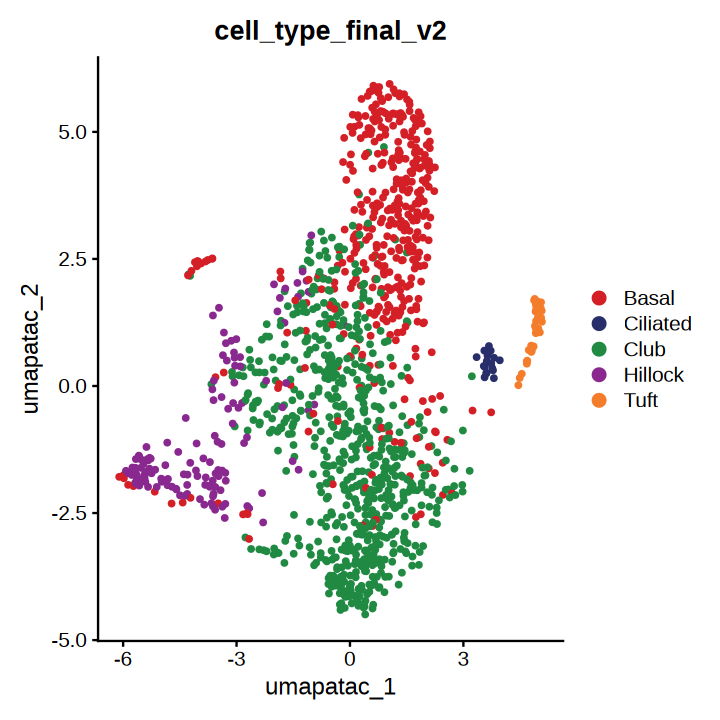

In [16]:
options(repr.plot.height = 6, repr.plot.width = 6)

DimPlot(obj.subset, group.by = "cell_type_final_v2", reduction = "umap_atac", 
cols = ArchR::paletteDiscrete(obj.subset$cell_type_final_v2))

In [17]:
obj.subset

An object of class Seurat 
172727 features across 1304 samples within 3 assays 
Active assay: RNA (16887 features, 0 variable features)
 1 layer present: data
 2 other assays present: ATAC, GeneActivity
 2 dimensional reductions calculated: lsi, umap_atac

In [18]:
DefaultAssay(obj.subset) <- "ATAC"

In [19]:
obj.subset <- FindTopFeatures(obj.subset, min.cutoff = "q1")
obj.subset <- RunTFIDF(obj.subset, method = 1)
obj.subset <- RunSVD(obj.subset, n = 30, scale.embeddings = FALSE)

Performing TF-IDF normalization

Running SVD



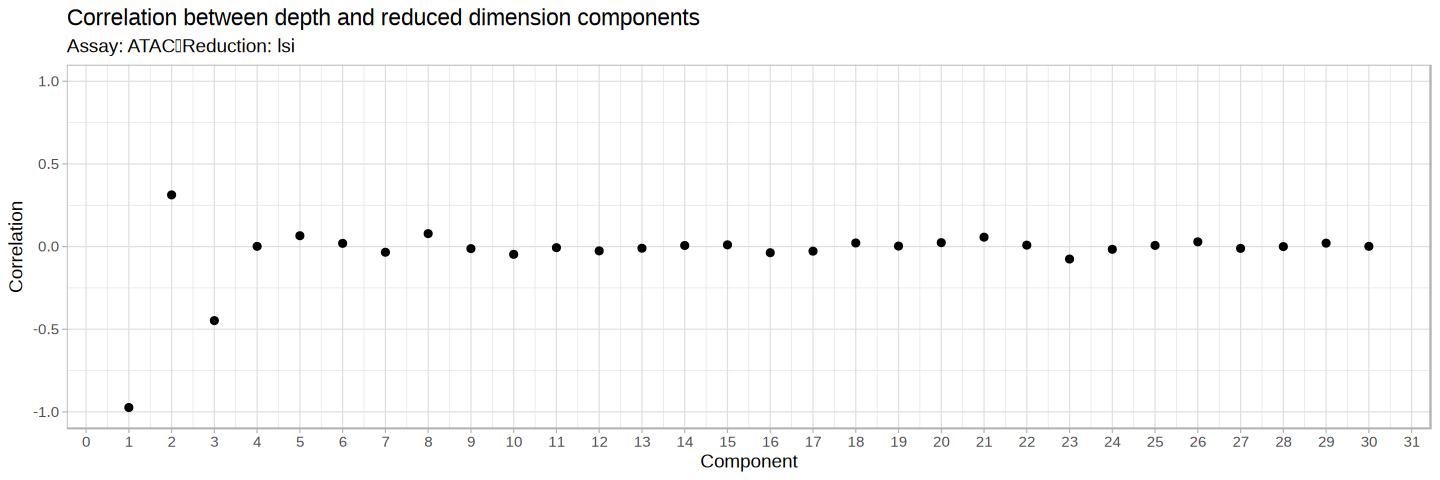

In [20]:
options(repr.plot.height = 4, repr.plot.width = 12)
DepthCor(obj.subset, reduction = 'lsi', n = 30)

In [21]:
obj.subset <- RunUMAP(object = obj.subset, 
               reduction = 'lsi',
               reduction.name = "umap_atac_v2",
               dims = 2:15, 
               metric = "euclidean",
               verbose = FALSE)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


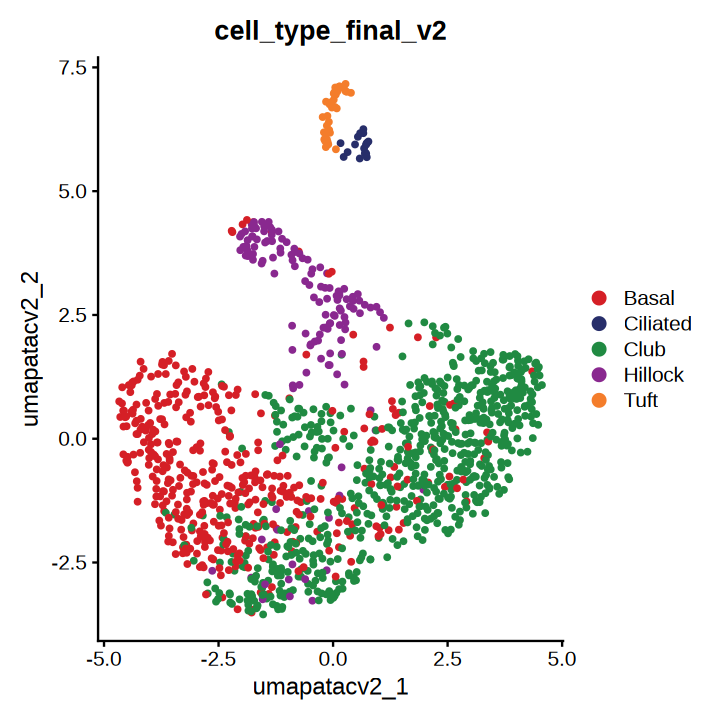

In [22]:
options(repr.plot.height = 6, repr.plot.width = 6)

DimPlot(obj.subset, group.by = "cell_type_final_v2", reduction = "umap_atac_v2", 
cols = ArchR::paletteDiscrete(obj.subset$cell_type_final_v2))

In [23]:
saveRDS(obj.subset,file = glue::glue("{out_dir}/obj.rds"))
write.csv(obj.subset@meta.data, file = glue::glue("{out_dir}/obj_metadata.csv"))